<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Unit_02/HW_2_3-HW_2_4/HW_2_4_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%B1%D1%83%D1%81%D1%82%D0%B8%D0%BD%D0%B3%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [30]:
!pip install mlxtend

In [31]:
!pip install xgboost lightgbm hyperopt

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)

# Training
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
from typing import Tuple

import xgboost as xgb
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

# Charts
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

import seaborn as sns
sns.set_style('darkgrid')

from mlxtend.plotting import plot_decision_regions


# Kaggle Setup

In [34]:
import os
from google.colab import userdata
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [35]:
# in case of error, rerun the cell, sometimes creds from the previoues cell take more time to load
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.set_config_value("username", userdata.get("KAGGLE_USERNAME"), quiet=True)
api.set_config_value("key", userdata.get("KAGGLE_API_TOKEN"), quiet=True)

In [36]:
def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    for file in files:
        print(file.name)

    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(f.name)
        )[1]
        for f in files if f.name.endswith('.csv')
    }

In [37]:
competition = "bank-customer-churn-prediction-dlu-course-c-4"

dfs = load_competition_data(competition)

raw_train_df = dfs["train"].set_index("id")
raw_test_df = dfs["test"].set_index("id")
raw_sample_submission = dfs["sample_submission"]

sample_submission.csv
test.csv
train.csv
sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
test.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv: Skipping, found more recently modified local copy (use --force to force download)


# Helper Functions

In [38]:
def predict_and_plot(model, inputs, targets, name=""):
    y_pred = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    cm = confusion_matrix(targets, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve
    axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
    axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"ROC Curve for {name}")
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=True)
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title(f"{name} Confusion Matrix")

    plt.tight_layout()
    plt.show()

    print(f"""===== {name} Results =====
    AUROC: {roc_auc:.4f}
    F1 Score: {f1:.4f}
    \n""")

    return y_pred, roc_auc


# Tasks

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

## Завдання 0.
Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [39]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ML for People/HW_2_3')

from process_bank_churn import preprocess_data, preprocess_new_data

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(
    df: pd.DataFrame,
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(
    df: pd.DataFrame,
    input_cols: list,
    target_col: str
    ) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [41]:
EXCLUDE_COLS = ["CustomerId", "Surname", "Exited"]
INPUT_COLS = raw_train_df.columns.difference(EXCLUDE_COLS)
TARGET_COL = "Exited"

train, val = split_train_val(
    df = raw_train_df,
    target_col = TARGET_COL,
    )

train_X, train_y = separate_inputs_targets(
    df = train,
    input_cols = INPUT_COLS,
    target_col = TARGET_COL
    )

val_X, val_y = separate_inputs_targets(
    df = val,
    input_cols = INPUT_COLS,
    target_col = TARGET_COL
    )

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [42]:
cat_cols = train_X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

for col in cat_cols:
    train_X[col] = train_X[col].astype('category')
    val_X[col] = val_X[col].astype('category')

Categorical columns: ['Gender', 'Geography']


## Завдання 2.
Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

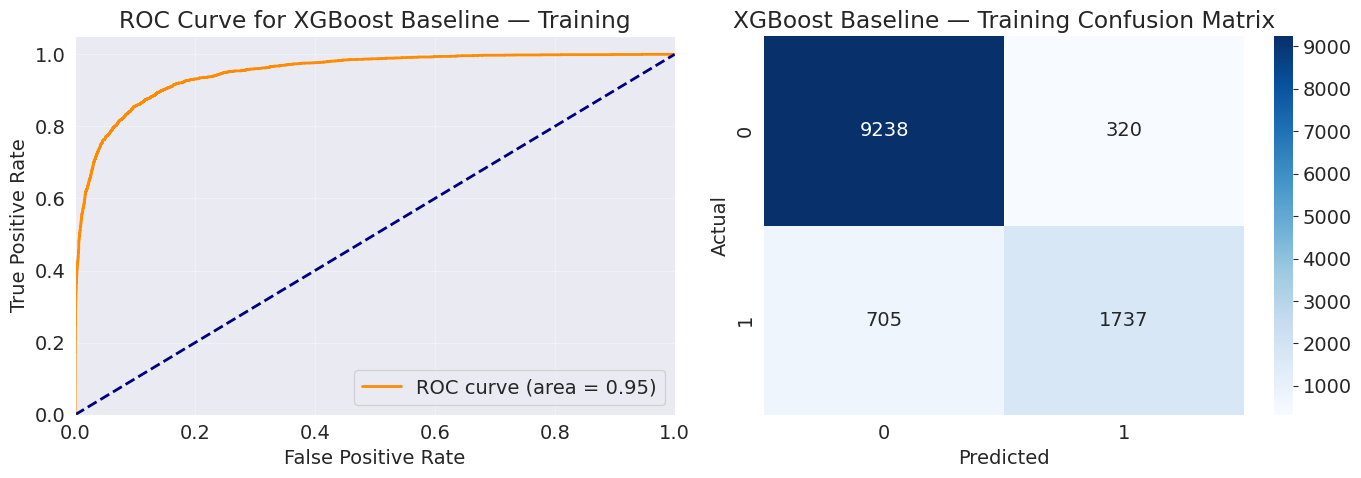

===== XGBoost Baseline — Training Results =====
    AUROC: 0.9506
    F1 Score: 0.7722
    



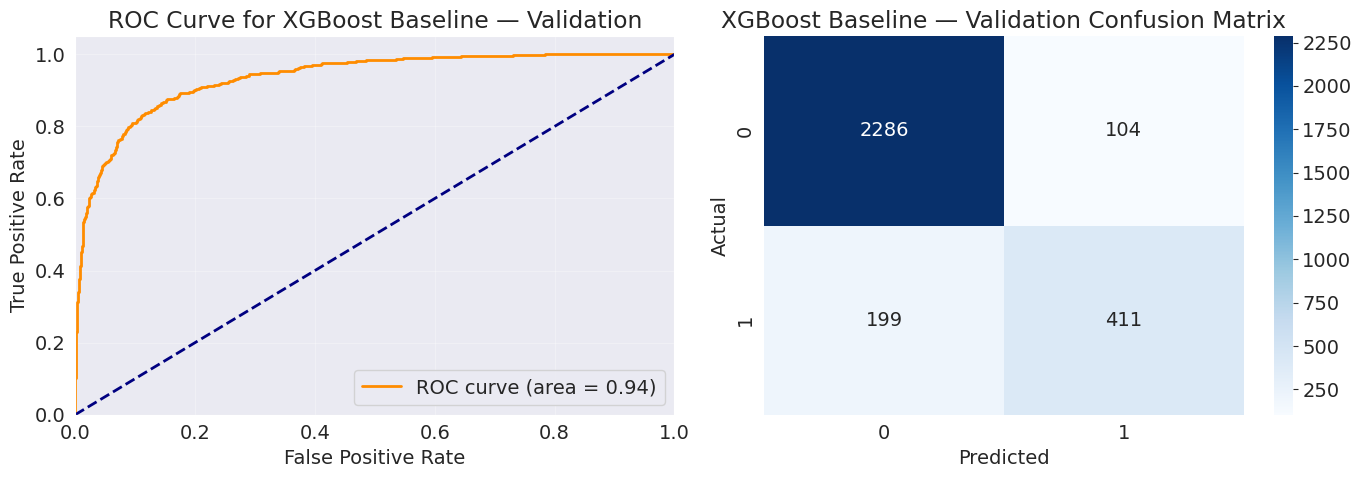

===== XGBoost Baseline — Validation Results =====
    AUROC: 0.9353
    F1 Score: 0.7307
    



In [43]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    enable_categorical=True,
    tree_method='hist',

    eval_metric='auc',
    random_state=42
)

xgb_clf.fit(train_X, train_y)

train_preds, train_auroc = predict_and_plot(xgb_clf, train_X, train_y, "XGBoost Baseline — Training")
val_preds, val_auroc = predict_and_plot(xgb_clf, val_X, val_y, "XGBoost Baseline — Validation")

**Висновок:**

Невелике перенавчання AUROC Train 0.9506 > AUROC Val 0.9353

Результат виглядає краще за отриманий в попередній домашній роботі

## Завдання 3.
Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [44]:
def objective_xgb(params):
    clf = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        min_child_weight=int(params['min_child_weight']),
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        random_state=42,
    )
    clf.fit(train_X, train_y)
    val_proba = clf.predict_proba(val_X)[:, 1]
    auroc = roc_auc_score(val_y, val_proba)

    # Hyperopt minimizes, so using -AUROC
    return {'loss': -auroc, 'status': STATUS_OK}

xgb_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'gamma': hp.uniform('gamma', 0, 5),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-8), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-8), np.log(10)),
}

xgb_trials = Trials()
best_xgb = fmin(
    fn=objective_xgb,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=20, # for task
    # max_evals=200, # for experiment
    trials=xgb_trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 20/20 [00:28<00:00,  1.40s/trial, best loss: -0.937053295836477]


In [45]:
print(f"\nBest XGBoost hyperparameters:")
for k, v in best_xgb.items():
    print(f"  {k}: {v}")


Best XGBoost hyperparameters:
  colsample_bytree: 0.7517149605448037
  gamma: 4.22980000436168
  learning_rate: 0.03305486342407529
  max_depth: 5.0
  min_child_weight: 10.0
  n_estimators: 300.0
  reg_alpha: 3.0669088589218005e-08
  reg_lambda: 0.08758452084004614
  subsample: 0.8893193614697442


In [46]:
# Train final XGBoost model with best params
final_clf = xgb.XGBClassifier(
    n_estimators=int(best_xgb['n_estimators']),
    max_depth=int(best_xgb['max_depth']),
    learning_rate=best_xgb['learning_rate'],
    subsample=best_xgb['subsample'],
    colsample_bytree=best_xgb['colsample_bytree'],
    min_child_weight=int(best_xgb['min_child_weight']),
    gamma=best_xgb['gamma'],
    reg_alpha=best_xgb['reg_alpha'],
    reg_lambda=best_xgb['reg_lambda'],
    enable_categorical=True,
    tree_method='hist',
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1,
)

final_clf.fit(train_X, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.7517149605448037), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=np.float64(4.22980000436168), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.03305486342407529), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

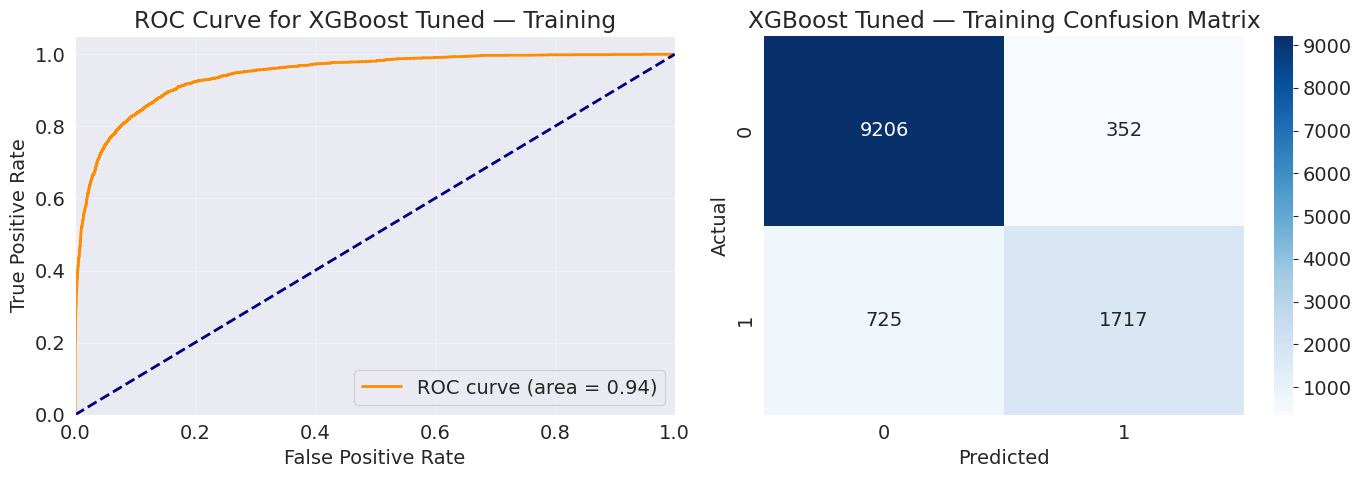

===== XGBoost Tuned — Training Results =====
    AUROC: 0.9447
    F1 Score: 0.7613
    



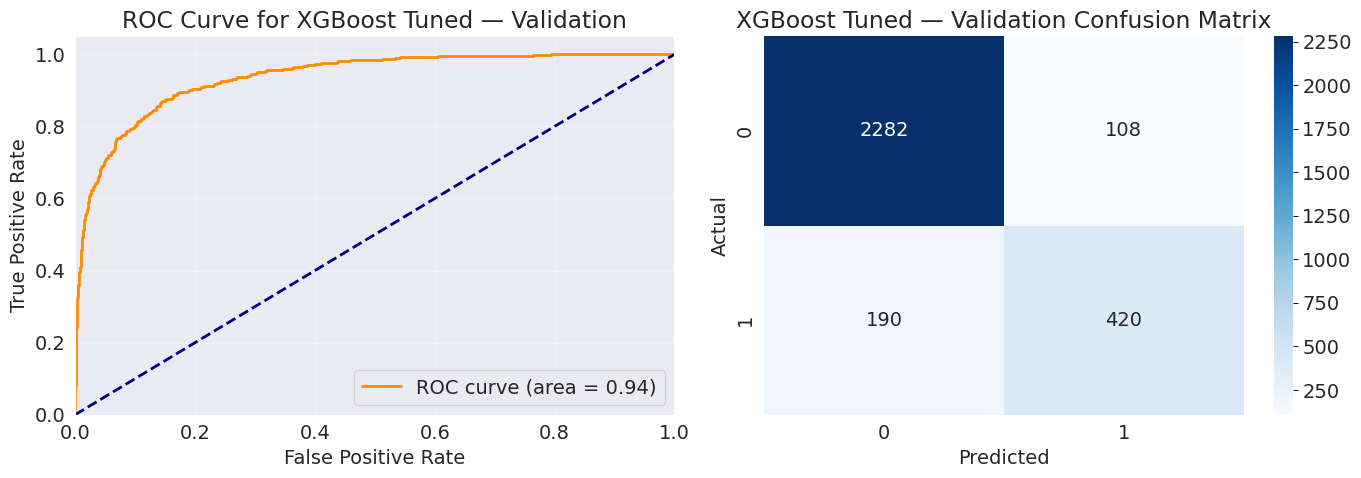

===== XGBoost Tuned — Validation Results =====
    AUROC: 0.9371
    F1 Score: 0.7381
    



In [47]:
train_preds_xgb_tuned, train_auroc_xgb_tuned = predict_and_plot(final_clf, train_X, train_y, "XGBoost Tuned — Training")
val_preds_xgb_tuned, val_auroc_xgb_tuned = predict_and_plot(final_clf, val_X, val_y, "XGBoost Tuned — Validation")

**Висновок**

Модель має менший train AUROC (0.9407 vs 0.9503) але трохи вищий Val AUROC (0.9373 vs 0.9370)

## Завдання 4.

Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [48]:
cat_feature_indexes = [train_X.columns.get_loc(col) for col in cat_cols]
print(cat_feature_indexes)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_clf.fit(train_X, train_y, categorical_feature=cat_feature_indexes)


[4, 5]


LGBMClassifier(colsample_bytree=0.8, max_depth=4, random_state=42,
               subsample=0.8, verbose=-1)

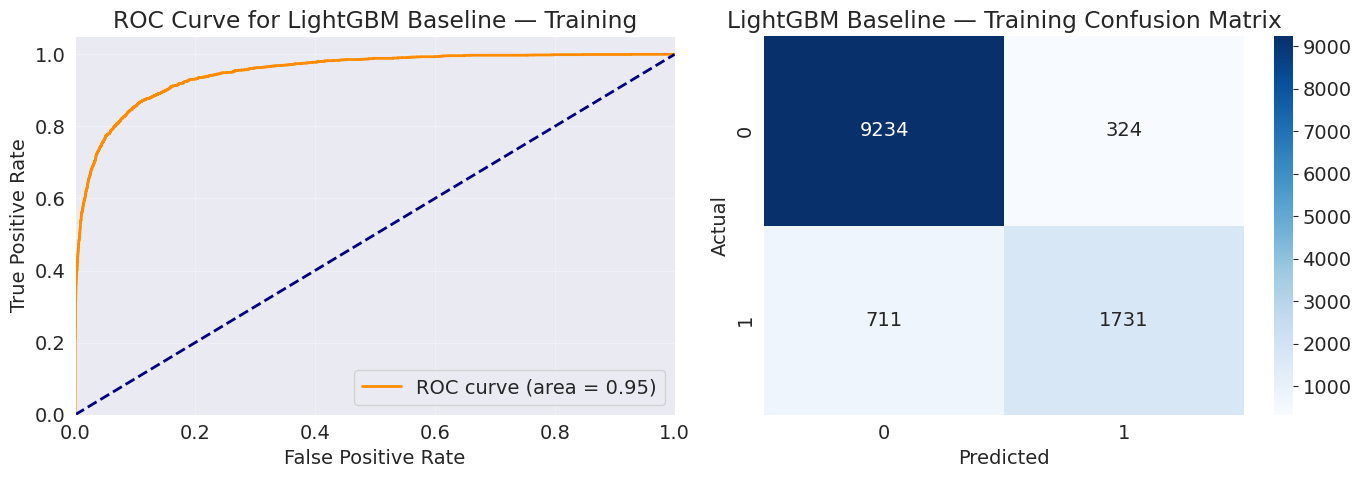

===== LightGBM Baseline — Training Results =====
    AUROC: 0.9510
    F1 Score: 0.7698
    



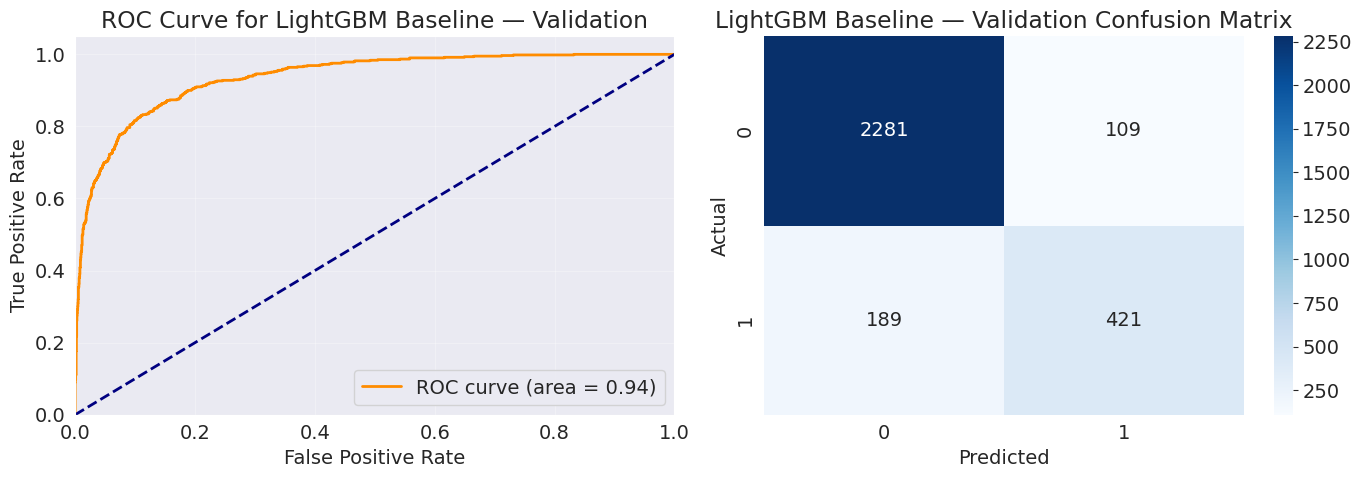

===== LightGBM Baseline — Validation Results =====
    AUROC: 0.9360
    F1 Score: 0.7386
    



In [49]:
train_preds_lgb, train_auroc_lgb = predict_and_plot(lgb_clf, train_X, train_y, "LightGBM Baseline — Training")
val_preds_lgb, val_auroc_lgb = predict_and_plot(lgb_clf, val_X, val_y, "LightGBM Baseline — Validation")

**Висновок:**

XGBoost трохи краще себе показав
LightGBM трохи перенавчився

# Завдання 5.
Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [51]:
def objective_lgb(params):
    clf = lgb.LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        num_leaves=int(params['num_leaves']),
        min_child_samples=int(params['min_child_samples']),
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        boosting_type=params['boosting_type'],
        random_state=42,
        verbose=-1,
        metric='auc',
        n_jobs=-1,
    )
    clf.fit(train_X, train_y, categorical_feature=cat_feature_indexes)
    val_proba = clf.predict_proba(val_X)[:, 1]
    auroc = roc_auc_score(val_y, val_proba)

    return {'loss': -auroc, 'status': STATUS_OK}

boosting_types = ['gbdt', 'dart', 'goss']
lgb_space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'num_leaves': hp.quniform('num_leaves', 15, 127, 1),
    'min_child_samples': hp.quniform('min_child_samples', 5, 100, 5),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-8), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-8), np.log(10)),
    'boosting_type': hp.choice('boosting_type', boosting_types),
}

lgb_trials = Trials()
best_lgb = fmin(
    fn=objective_lgb,
    space=lgb_space,
    algo=tpe.suggest,
    max_evals=10, # for task
    # max_evals=200, # for experiment
    trials=lgb_trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 10/10 [00:20<00:00,  2.03s/trial, best loss: -0.9368187118458058]


In [52]:
print(f"\nBest LightGBM hyperparameters:")
for k, v in best_lgb.items():
    print(f"  {k}: {v}")


Best LightGBM hyperparameters:
  boosting_type: 0
  colsample_bytree: 0.7367490548689456
  learning_rate: 0.010188411809459156
  max_depth: 9.0
  min_child_samples: 15.0
  n_estimators: 300.0
  num_leaves: 22.0
  reg_alpha: 0.5602402888065959
  reg_lambda: 0.0029801797509298408
  subsample: 0.7201685419162034


In [53]:
# Train final LightGBM model with best params
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=int(best_lgb['n_estimators']),
    max_depth=int(best_lgb['max_depth']),
    learning_rate=best_lgb['learning_rate'],
    subsample=best_lgb['subsample'],
    colsample_bytree=best_lgb['colsample_bytree'],
    num_leaves=int(best_lgb['num_leaves']),
    min_child_samples=int(best_lgb['min_child_samples']),
    reg_alpha=best_lgb['reg_alpha'],
    reg_lambda=best_lgb['reg_lambda'],
    boosting_type=boosting_types[int(best_lgb['boosting_type'])],
    random_state=42,
    verbose=-1
)

final_lgb_clf.fit(train_X, train_y, categorical_feature=cat_feature_indexes)

LGBMClassifier(colsample_bytree=np.float64(0.7367490548689456),
               learning_rate=np.float64(0.010188411809459156), max_depth=9,
               min_child_samples=15, n_estimators=300, num_leaves=22,
               random_state=42, reg_alpha=np.float64(0.5602402888065959),
               reg_lambda=np.float64(0.0029801797509298408),
               subsample=np.float64(0.7201685419162034), verbose=-1)

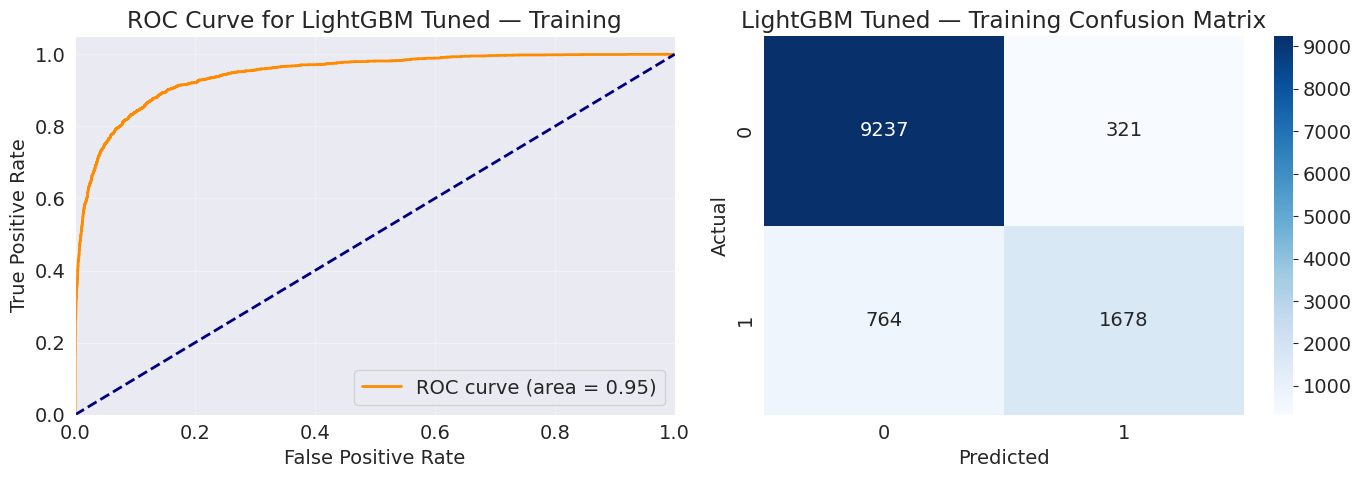

===== LightGBM Tuned — Training Results =====
    AUROC: 0.9456
    F1 Score: 0.7557
    



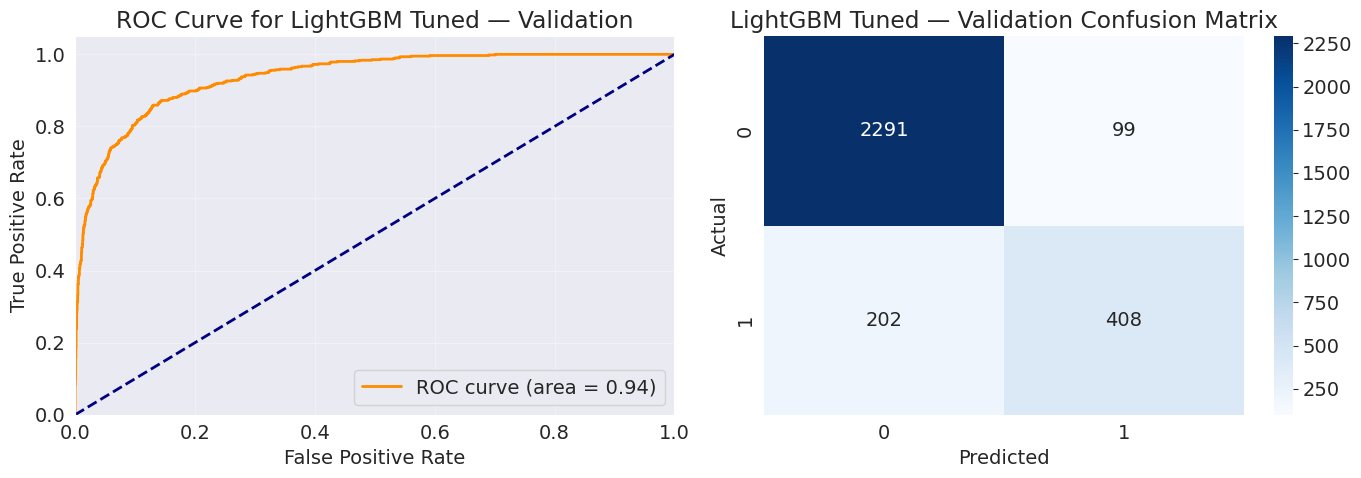

===== LightGBM Tuned — Validation Results =====
    AUROC: 0.9368
    F1 Score: 0.7305
    



In [54]:
train_preds_lgb_tuned, train_auroc_lgb_tuned = predict_and_plot(final_lgb_clf, train_X, train_y, "LightGBM Tuned — Training")
val_preds_lgb_tuned, val_auroc_lgb_tuned = predict_and_plot(final_lgb_clf, val_X, val_y, "LightGBM Tuned — Validation")

Краще ща попереднє, але гірше за XGBoost Hyperopt, але ж і раундів тут менше було

## Завдання 6.
Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [55]:
best_model = final_clf  # XGBoost Hyperopt

In [56]:
test_X = raw_test_df[INPUT_COLS]
for col in cat_cols:
    test_X[col] = test_X[col].astype('category')

test_preds = best_model.predict_proba(test_X)[:, 1]

submission = raw_sample_submission.copy()
submission["Exited"] = test_preds

submission.to_csv("submission_xgboost_hyperopt.csv", index=False)
submission.head()


,id,Exited
0,15000,0.079669
1,15001,0.020200
2,15002,0.060945
3,15003,0.521053
4,15004,0.035342


Обирала за AUROC значенням для валідаційного набору :)